In [1]:
#Import data
import pandas as pd

df = pd.read_csv("heart_disease.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# finding target to sort
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [3]:
# features and Target
X = df.drop('target', axis=1)
y = df['target']

In [4]:
# Train - Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [6]:
# Prediction + Accuracy
from sklearn.metrics import accuracy_score

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366


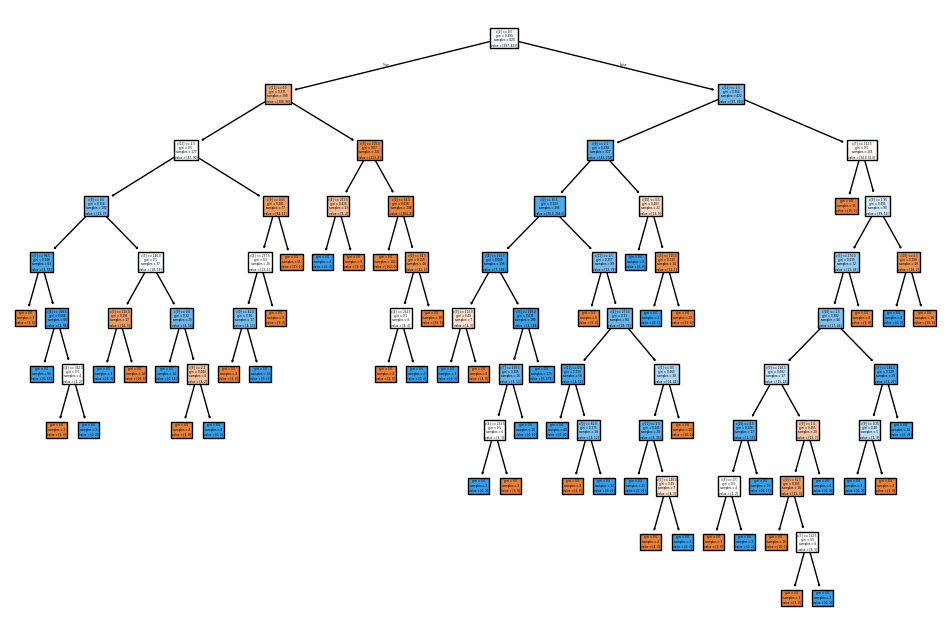

In [7]:
# Tree Visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(dt_model, filled=True)
plt.show()

In [8]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


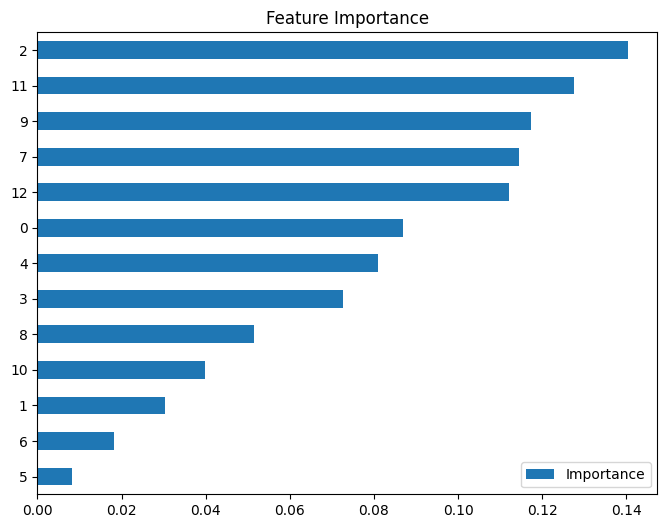

In [9]:
# Features Importance
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance.sort_values(by='Importance').plot(
    kind='barh', figsize=(8,6)
)
plt.title("Feature Importance")
plt.show()

# Insight:
# Features like cp and thalach have strong impact on prediction

In [10]:
# Overfitting control
dt_model2 = DecisionTreeClassifier(max_depth=3)
dt_model2.fit(X_train, y_train)

y_pred_dt2 = dt_model2.predict(X_test)

print("Controlled Tree Accuracy:", accuracy_score(y_test, y_pred_dt2))

Controlled Tree Accuracy: 0.7804878048780488


In [11]:
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

# Insight:
# Model is stable as cross-validation score is consistent

Cross Validation Scores: [1.         1.         1.         1.         0.98536585]
Mean CV Score: 0.9970731707317073


In [12]:
# Accuracy Comparison
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Insight:
# Random Forest > Decision Tree

Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 0.9853658536585366


Insight:
Random Forest model gives higher accuracy compared to Decision Tree,
which shows the benefit of ensemble learning.
